# Lecture 2 — Class Exercise
# Bar Charts: World Happiness Report 2023

---

> **Your task:** Create **2 polished bar charts** using the World Happiness Report dataset.  
> **Push to:** `week02/lecture02_exercise.ipynb` in **your own GitHub repo** before the end of class.

---

### Rules (these will be checked in the model answer review next week)
1. Every bar chart **must have a zero baseline** — no exceptions (SWD p.51)
2. Every chart **must have an insight title**, not a topic title (SWD p.29)
3. Aim for **professional quality** — clean background, readable font, no clutter
4. Horizontal bars for long category names (SWD p.57)

---


## Setup — Run this cell first


In [1]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('../data/world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())


Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


In [2]:
import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])


Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

---
## Task 1 — Regional Comparison Bar Chart

**What to build:** A horizontal bar chart showing the **average happiness score by region**, sorted from highest to lowest.

**Requirements:**
- Horizontal orientation (category names are long)
- Sorted by score, descending (so the happiest region is at the top)
- Zero baseline on x-axis
- At least one design choice that goes beyond the Plotly default (colour, annotation, labels, etc.)
- An insight title that answers: *which region stands out and why does it matter?*

**Hint:** Use `df.groupby('Region')['Happiness_Score'].mean()` to compute the averages.


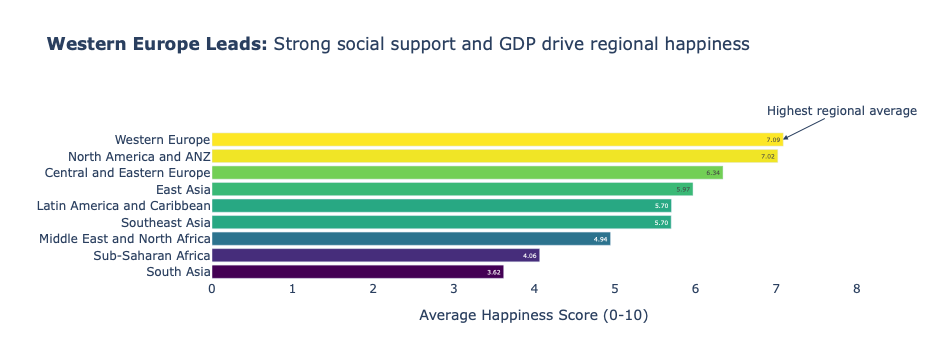

In [3]:
# Task 1: Regional Comparison

# Step 1: Compute averages
region_avg = (
    df.groupby('Region')['Happiness_Score']
    .mean()
    .reset_index()
    .sort_values('Happiness_Score')
)

# Step 2: Create chart
import plotly.express as px

fig1 = px.bar(
    region_avg,
    x='Happiness_Score',
    y='Region',
    orientation='h',
    text_auto='.2f',
    title="<b>Western Europe Leads:</b> Strong social support and GDP drive regional happiness",
    color='Happiness_Score',
    color_continuous_scale='Viridis'
)

# Step 3: Styling
fig1.update_layout(
    xaxis=dict(title="Average Happiness Score (0-10)", range=[0, 8]),
    yaxis=dict(title=""),
    plot_bgcolor='white',
    margin=dict(l=150),
    coloraxis_showscale=False
)

# Step 4: Annotation
fig1.add_annotation(
    x=7.08,
    y="Western Europe",
    text="Highest regional average",
    showarrow=True,
    arrowhead=2,
    ax=60,
    ay=-30
)

fig1.show()



---
## Task 2 — Bottom vs. Top: A Contrast Story

**What to build:** A bar chart that highlights the **gap between the happiest and least happy countries**, focusing on a specific insight.

**Requirements:**
- Show the **top 8 AND bottom 8 countries** together (16 bars total)
- Use **colour** to distinguish the two groups (not Plotly's default rainbow)
- Add a **visual separator or annotation** that emphasises the gap
- Insight title that tells the story of the gap

**Hint:** Use `pd.concat([df.nlargest(8,'Happiness_Score'), df.nsmallest(8,'Happiness_Score')])` to get both groups.

**Stretch goal:** Add a vertical reference line showing the global average.


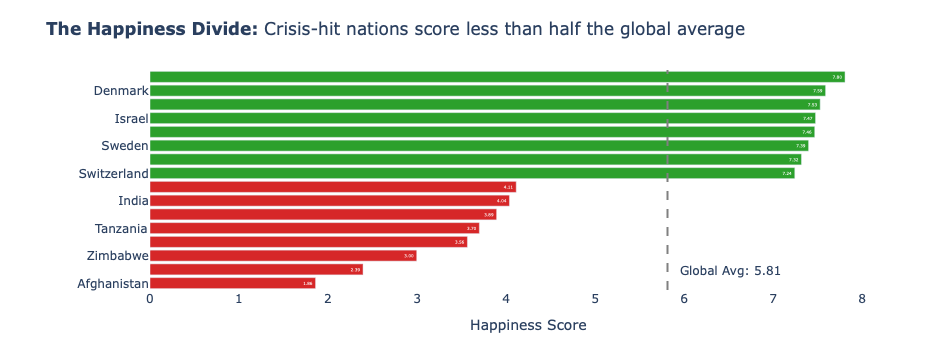

In [4]:
# Task 2: Top vs Bottom Countries

# Step 1: Get top and bottom
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'

bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')

global_avg = df['Happiness_Score'].mean()

# Step 2: Chart
fig2 = px.bar(
    combined,
    x='Happiness_Score',
    y='Country',
    color='Group',
    orientation='h',
    text_auto='.2f',
    title="<b>The Happiness Divide:</b> Crisis-hit nations score less than half the global average",
    color_discrete_map={'Top 8': '#2ca02c', 'Bottom 8': '#d62728'}
)

# Step 3: Styling
fig2.update_layout(
    plot_bgcolor='white',
    xaxis=dict(title="Happiness Score", range=[0, 8.5]),
    yaxis=dict(title=""),
    margin=dict(l=150, r=20, t=70, b=70),
    showlegend=False
)

# Step 4: Global average line
fig2.add_vline(x=global_avg, line_dash="dash", line_color="gray")

fig2.add_annotation(
    x=global_avg,
    y=1,
    text=f"Global Avg: {global_avg:.2f}",
    showarrow=False,
    xanchor="left",
    xshift=10
)

fig2.show()



---
## Done? Stretch Goal

If you finish both tasks with time to spare, try this:

**Task 3 (stretch):** Build a **grouped bar chart** comparing 2 sub-factors (e.g. `GDP_per_capita` and `Freedom`) across the 5 most populated regions. Use colour meaningfully and write an insight title.

Regions to include: `'Western Europe'`, `'Latin America'`, `'East Asia'`, `'Sub-Saharan Africa'`, `'South Asia'`


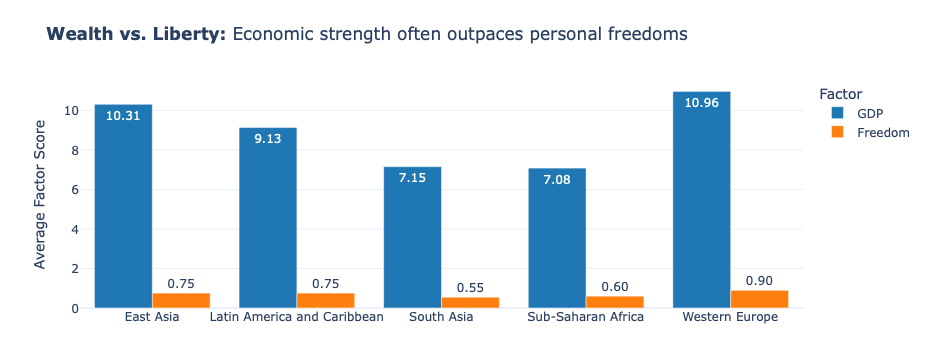

In [5]:
# Task 3: Grouped Bar Chart

target_regions = [
    'Western Europe',
    'Latin America and Caribbean',
    'East Asia',
    'Sub-Saharan Africa',
    'South Asia'
]

df_filtered = df[df['Region'].isin(target_regions)]

factors = (
    df_filtered.groupby('Region')[['GDP', 'Freedom']]
    .mean()
    .reset_index()
    .melt(id_vars='Region', var_name='Factor', value_name='Score')
)

fig3 = px.bar(
    factors,
    x='Region',
    y='Score',
    color='Factor',
    barmode='group',
    text_auto='.2f',
    title="<b>Wealth vs. Liberty:</b> Economic strength often outpaces personal freedoms",
    color_discrete_sequence=['#1f77b4', '#ff7f0e'],
    template='plotly_white'
)

fig3.update_layout(
    xaxis_title="",
    yaxis_title="Average Factor Score",
    legend_title="Factor",
    margin=dict(t=80, b=50)
)

fig3.show()